In [1]:
from langgraph.graph import START,StateGraph,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
llm=ChatOpenAI()

In [3]:
class JokeState(TypedDict):

    topic:str
    joke:str
    explanation:str

In [4]:
def generate_joke(state:JokeState):
    prompt=f'generate a joke this topic - {state["topic"]}'
    response=llm.invoke(prompt).content

    return {"joke":response}

In [5]:
def generate_explanation(state:JokeState):

    prompt=f"Write an explanation for the joke - {state['joke']}"
    response=llm.invoke(prompt).content

    return {"explanation":response}

In [6]:
graph=StateGraph(JokeState)

graph.add_node('gen_joke',generate_joke)
graph.add_node('gen_exp',generate_explanation)

graph.add_edge(START,"gen_joke")
graph.add_edge("gen_joke","gen_exp")
graph.add_edge("gen_exp",END)

checkpointer=InMemorySaver()

workflow=graph.compile(checkpointer=checkpointer)

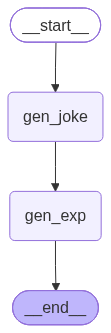

In [7]:
workflow

In [8]:
config1={"configurable":{"thread_id":"1"}}
workflow.invoke({"topic":"pizza"},config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the dentist?\n\nTo get a little "dough-cay" for its cavity!',
 'explanation': 'This joke plays on the dual meaning of the word "dough." In the context of pizza, "dough" refers to the bread-like base of the pizza. However, in the context of visiting the dentist, "dough" is a slang term for money. So, the joke is that the pizza went to the dentist to get some money (dough) for its cavity, which is a playful way of saying that the pizza needed to pay for dental treatment.'}

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the dentist?\n\nTo get a little "dough-cay" for its cavity!', 'explanation': 'This joke plays on the dual meaning of the word "dough." In the context of pizza, "dough" refers to the bread-like base of the pizza. However, in the context of visiting the dentist, "dough" is a slang term for money. So, the joke is that the pizza went to the dentist to get some money (dough) for its cavity, which is a playful way of saying that the pizza needed to pay for dental treatment.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d6e3-2123-6c43-8002-71c2b9dd2345'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-01T05:59:45.117088+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d6e3-0f95-6f60-8001-1a9a768438f6'}}, tasks=(), interrupts=())

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the dentist?\n\nTo get a little "dough-cay" for its cavity!', 'explanation': 'This joke plays on the dual meaning of the word "dough." In the context of pizza, "dough" refers to the bread-like base of the pizza. However, in the context of visiting the dentist, "dough" is a slang term for money. So, the joke is that the pizza went to the dentist to get some money (dough) for its cavity, which is a playful way of saying that the pizza needed to pay for dental treatment.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d6e3-2123-6c43-8002-71c2b9dd2345'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-01T05:59:45.117088+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d6e3-0f95-6f60-8001-1a9a768438f6'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did th

### Time Travel - debugging


In [11]:
workflow.get_state({"configurable":{"thread_id":"1","checkpoint_id":"1f18d6a2-0836-6a12-8000-6aa0658db18b"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f18d6a2-0836-6a12-8000-6aa0658db18b'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [13]:
workflow.invoke(None,{"configurable":{"thread_id":"1","checkpoint_id":"1f18d6e3-0252-65c2-bfff-b752e11f5037"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was having trouble with its crust!',
 'explanation': 'This joke plays on the double meaning of the word "crust." On one hand, crust refers to the outer layer of the pizza dough. However, in this context, the joke suggests that the pizza was having trouble with its "crust" in the sense of being emotionally unstable or distressed. So, the pizza went to the doctor to seek help for its issues with its crust.'}

In [14]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was having trouble with its crust!', 'explanation': 'This joke plays on the double meaning of the word "crust." On one hand, crust refers to the outer layer of the pizza dough. However, in this context, the joke suggests that the pizza was having trouble with its "crust" in the sense of being emotionally unstable or distressed. So, the pizza went to the doctor to seek help for its issues with its crust.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d6e4-b2d9-6325-8003-36beeca1b4bb'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-01T06:00:27.239299+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d6e4-a60b-6e0b-8002-760818f85cd5'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it 

### Update state

In [15]:
workflow.update_state({"configurable":{"thread_id":"1","checkpoint_id":"1f18d6e3-0252-65c2-bfff-b752e11f5037","checkpoint_ns":""}},{"topic":"samosa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18d6e5-b312-64e6-8000-e79282121f31'}}

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d6e5-b312-64e6-8000-e79282121f31'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-08-01T06:00:54.106237+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d6e3-0252-65c2-bfff-b752e11f5037'}}, tasks=(PregelTask(id='3bcb8436-7aac-c1de-ea84-d865d9792567', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was having trouble with its crust!', 'explanation': 'This joke plays on the double meaning of the word "crust." On one hand, crust refers to the outer layer of the pizza dough. However, in this context, the joke suggests that the pizza was having trouble with its "crust" in the sense of being e

In [17]:
workflow.invoke(None,{"configurable":{"thread_id":"1","checkpoint_id":"1f18d6e5-b312-64e6-8000-e79282121f31"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to school? \n\nBecause it wanted to become a corn-ist!',
 'explanation': 'This joke plays on the pun of the word "corn-ist" sounding similar to "corniest." A samosa is a popular Indian snack that is typically filled with spiced potatoes or other ingredients. In this joke, the samosa\'s desire to become the "corniest" (or most corny) suggests that it wants to study and learn in order to become the best at making corny jokes. The humor comes from the unexpected punchline and the absurdity of a samosa attending school to become a master of corny humor.'}